In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [ ]:
# ===== Cell 1: Install =====
!pip install -q torch transformers datasets scikit-learn pandas matplotlib seaborn

In [ ]:
# ===== Cell 2: Load CSV=====
import pandas as pd

# ============================================================
# LOAD DATASETS
#   Downloaded from the HF Hub dataset repo:
#     https://huggingface.co/datasets/shariul-islam/simulation1_dataset
# ============================================================
from huggingface_hub import hf_hub_download

HF_DATASET_REPO = "shariul-islam/simulation1_dataset"

CSV_PATH = hf_hub_download(
    repo_id=HF_DATASET_REPO,
    filename="BangalaBarta bangla_spam_sms smishing.csv",
    repo_type="dataset",
)

print("Using:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print("Raw rows:", len(df))

(…)laBarta%20bangla_spam_sms%20smishing.csv:   0%|          | 0.00/514k [00:00<?, ?B/s]

Using: /root/.cache/huggingface/hub/datasets--shariul-islam--simulation1_dataset/snapshots/61da11c8ac1de5e3408a8a8151a69a3a0d7fda50/BangalaBarta bangla_spam_sms smishing.csv
Raw rows: 2772


In [ ]:
df.head()

,label,text
0,smish,সোনালী ব্যাংক অ্যাকাউন্টে সমস্যা হয়েছে। কল কর...
1,smish,ক্রিপ্টো বিনিয়োগে লাভবান হন! আজই শুরু করুন: h...
2,promo,"স্পেশাল ডিল শেষ দিন,৩০জিবি @৩০০৳,৩০দিন! আজই না..."
3,promo,ফার্নিচারে মেগা সেল! সব পণ্যে ১৫-৩০% ছাড়। আজই...
4,smish,আপনার ব্যাংক কার্ডটি অবিলম্বে আপডেট করুন। এখান...


In [ ]:
# ===== Cell 3: Imports + cleaning (§III-B) =====
import re, torch, numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Your HF labels are lowercase strings
LABELS = {"normal": 0, "promo": 1, "smish": 2}

# §III-B: keep only Bangla Unicode \u0980-\u09FF, normalize whitespace
def clean(t):
    t = re.sub(r"[^\u0980-\u09FF\s]", " ", str(t))
    return re.sub(r"\s+", " ", t).strip()

df["text"] = df["text"].map(clean)
df = df[df["text"].str.len() > 0].reset_index(drop=True)
df["label"] = df["label"].map(LABELS)
texts, labels = df["text"].tolist(), df["label"].tolist()
print(df["label"].value_counts())

Device: cuda
label
0    924
2    922
1    912
Name: count, dtype: int64


In [ ]:
# ===== Cell 4: Tokenizers (§III-C, §III-D) =====
BERT_NAME = "bert-base-multilingual-cased"          # §III-C
MAX_TOK = 128
tok = AutoTokenizer.from_pretrained(BERT_NAME)

MAX_CHAR = 256                                       # §III-D
def build_char_vocab(ts):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for c in sorted(set("".join(ts))):
        vocab[c] = len(vocab)
    return vocab
cvocab = build_char_vocab(texts)

def encode_chars(t):                                 # Eq.(1): E=min(L,256)
    ids = [cvocab.get(c, 1) for c in t][:MAX_CHAR]
    return ids + [cvocab["<PAD>"]] * (MAX_CHAR - len(ids))

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
# ===== Cell 5: Dataset + Hybrid model (§III-E) =====
class SMSData(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        enc = tok(self.X[i], max_length=MAX_TOK, padding="max_length",
                  truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "char_ids": torch.tensor(encode_chars(self.X[i])),
                "label": torch.tensor(self.y[i])}

class HybridCNNBERT(nn.Module):                       # §III-E
    def __init__(self, char_vocab_size, n_classes=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BERT_NAME)
        self.char_emb = nn.Embedding(char_vocab_size, 128, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(128, 100, k, padding=k//2) for k in (3,4,5)])
        self.attn = nn.MultiheadAttention(768, 8, batch_first=True)
        self.fc1 = nn.Linear(768 + 300, 256)
        self.drop = nn.Dropout(0.3)
        self.out = nn.Linear(256, n_classes)
    def forward(self, input_ids, attention_mask, char_ids):
        seq = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a, _ = self.attn(seq, seq, seq)
        word_feat = a.mean(dim=1)
        c = self.char_emb(char_ids).transpose(1, 2)
        char_feat = torch.cat([torch.relu(cv(c)).max(dim=2).values for cv in self.convs], dim=1)
        h = self.drop(torch.relu(self.fc1(torch.cat([word_feat, char_feat], dim=1))))
        return self.out(h)

In [ ]:
# ===== Cell 6: Training (§III-F, §III-G) + 5-fold CV (§IV-C) =====
def run_fold(tr_idx, va_idx, epochs=3):              # §III-G: 3 epochs
    model = HybridCNNBERT(len(cvocab)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-5)  # AdamW, lr 2e-5
    crit = nn.CrossEntropyLoss()                          # cross-entropy
    tr = DataLoader(SMSData([texts[i] for i in tr_idx], [labels[i] for i in tr_idx]),
                    batch_size=16, shuffle=True)
    va = DataLoader(SMSData([texts[i] for i in va_idx], [labels[i] for i in va_idx]),
                    batch_size=16)
    for ep in range(epochs):
        model.train()
        for b in tr:
            opt.zero_grad()
            loss = crit(model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE),
                              b["char_ids"].to(DEVICE)), b["label"].to(DEVICE))
            loss.backward(); opt.step()
    model.eval(); preds, gts = [], []
    with torch.no_grad():
        for b in va:
            logits = model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE),
                           b["char_ids"].to(DEVICE))
            preds += logits.argmax(1).cpu().tolist(); gts += b["label"].tolist()
    return gts, preds

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # §IV-C
all_g, all_p, fold_acc = [], [], []
for f, (tr, va) in enumerate(skf.split(texts, labels)):
    g, p = run_fold(tr, va)
    all_g += g; all_p += p
    acc = float(np.mean(np.array(g) == np.array(p)))
    fold_acc.append(acc); print(f"Fold {f+1} accuracy: {acc:.4f}")



model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fold 1 accuracy: 0.9764


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fold 4 accuracy: 0.9873


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fold 5 accuracy: 0.9855


In [ ]:
print(f"\nMean CV accuracy: {np.mean(fold_acc):.4f}  (paper: 0.9852)")
print(classification_report(all_g, all_p, target_names=["Normal","Promo","Smish"], digits=4))


Mean CV accuracy: 0.9811  (paper: 0.9852)
              precision    recall  f1-score   support

      Normal     0.9870    0.9827    0.9848       924
       Promo     0.9814    0.9846    0.9830       912
       Smish     0.9751    0.9761    0.9756       922

    accuracy                         0.9811      2758
   macro avg     0.9812    0.9812    0.9812      2758
weighted avg     0.9812    0.9811    0.9811      2758



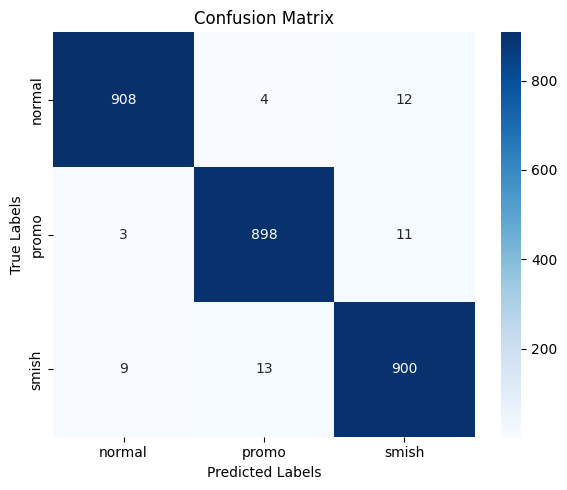

In [ ]:
# ===== Cell 7: Confusion matrix (Fig. 3) =====
cm = confusion_matrix(all_g, all_p)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal","promo","smish"],
            yticklabels=["normal","promo","smish"])
plt.xlabel("Predicted Labels"); plt.ylabel("True Labels"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=200); plt.show()